# ALS_LLRF_MTS test on ZCU208
---

The following results were captured when looping back all 8 DACs to 8 ADCs through equal-length cables.


### Preparation from a PYNQ 3.0.1 image:

Run installation script: `./pynq_llrf/install.sh`.

In [ ]:
%cd /home/xilinx/jupyter_notebooks/pynq_llrf

/home/xilinx/jupyter_notebooks/pynq_llrf


In [ ]:
from mimo_mts.overlay import MimoMtsOverlay
import numpy as np
from mimo_mts.utils.plot import plot_complex_wfm_stack

%load_ext autoreload
%autoreload 2

In [4]:
ol = MimoMtsOverlay(config='ALS_LLRF_ZCU208')

In [5]:
ol

< MimoMtsOverlay >:
{ 'bitfile_name': 'als_llrf_mts.bit',
  'board': 'ZCU208',
  'clk104_tcs': { 'lmk_tcs': 'mimo_mts/utils/clk104/LMK04828_500M_CLKin0.tcs',
                  'lmxadc_tcs': 'mimo_mts/utils/clk104/LMX2594_4G.tcs',
                  'lmxdac_tcs': 'mimo_mts/utils/clk104/LMX2594_4G.tcs'},
  'rfdc': { 'adc_decimation_factor': 8,
            'adc_mixer_nco_freq_mhz': 3000,
            'adc_mixer_nco_nyquist': 2,
            'dac_interplation_factor': 8,
            'dac_mixer_nco_freq_mhz': -3000,
            'dac_mixer_nco_nyquist': 2,
            'mts_adc_target_latency': 96,
            'mts_dac_target_latency': 256},
  'si570_freq_mhz': 156.1375}
RFDC MTS Latency Report:
DAC Tile 0 Latency: 256, Offset: 2
DAC Tile 1 Latency: 256, Offset: 2
DAC Tile 2 Latency: 256, Offset: 2
DAC Tile 3 Latency: 256, Offset: 2
ADC Tile 0 Latency:  96, Offset: 1
ADC Tile 1 Latency:  96, Offset: 1
ADC Tile 2 Latency:  96, Offset: 1
ADC Tile 3 Latency:  96, Offset: 1

In [6]:
ol.clk104

< CLK104Config >:
  === LMK04828: ===
part            :    LMK04828B
SYSREF_FREQ     :        4.996 MHz
OSCout_FREQ     :      160.009 MHz
CLKin0_FREQ     :      499.640 MHz
CLKin1_FREQ     :       10.000 MHz
CLKin2_FREQ     :       76.800 MHz
CLKout0_FREQ    :      499.640 MHz
CLKout1_FREQ    :        4.996 MHz
CLKout2_FREQ    :      499.640 MHz
CLKout3_FREQ    :        4.996 MHz
CLKout4_FREQ    :      499.640 MHz
CLKout5_FREQ    :        4.996 MHz
CLKout6_FREQ    :      499.640 MHz
CLKout7_FREQ    :        4.996 MHz
CLKout8_FREQ    :      499.640 MHz
CLKout9_FREQ    :        4.996 MHz
CLKout10_FREQ   :      499.640 MHz
CLKout11_FREQ   :        4.996 MHz
CLKout12_FREQ   :      499.640 MHz
CLKout13_FREQ   :        4.996 MHz
CLKin_SEL_MODE  :       CLKin0
VCO_MUX         :         VCO0
  === LMX2594 ADC: ===
part            :      LMX2594
Fosc_FREQ       :      499.640 MHz
FoutA_FREQ      :     3997.120 MHz
FoutB_FREQ      :     3997.120 MHz
Fpd_FREQ        :      249.820 MHz
Fvco_FREQ 

# Configure trigger and DSP

In [7]:
fs = ol.board.adc_sampling_rate
fs = fs / 8  # after decimation
start = 210 # start of the signal, measured
print(f'RF loop back latency: {start / fs * 1e9} ns')

RF loop back latency: 420.0 ns


In [8]:
ol.rf_control.register_map.trig_period = 250e6
ol.rf_control.register_map.trig_sel = 0  # internal trigger
ol.rf_control.register_map.trig_delay = 0
ol.rf_control.register_map.trig_divide = 1
ol.rf_control.register_map.dac_enable = 1
ol.rf_control.register_map.pulse_length = 4096
ol.rf_control.register_map.amp_loop_setpoint = 0

In [ ]:
dac_i = np.ones(ol.dac_player.size//2, dtype=np.int16) * 32767
dac_q = np.zeros_like(dac_i)
pulse_length_ns = 256  # short pulse
n_samples = int(pulse_length_ns / 1e9 * fs)
dac_i[n_samples:] = 0
ol.write_dac_iq_buf(dac_i, dac_q)

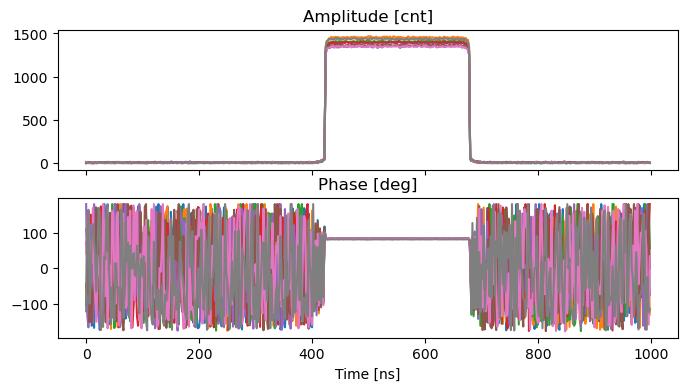

In [10]:
darray_i, darray_q = ol.capture_adc_iq_buf();
cdata = darray_i + 1j*darray_q
plot_complex_wfm_stack(cdata[:, :500], fs=fs, mode='ap', legend=False)

In [11]:
def get_dsp_waveform(ol=ol):
    """
    Get the DSP waveform from the ADC buffer.
    Average ADC data by 2 samples, as the same to the LLRF DSP,
    equivalent to a low pass filter to get base band signal.
    """
    darray_i, darray_q = ol.capture_adc_iq_buf()
    cdata = darray_i + 1j*darray_q
    return cdata.reshape(8, -1, 2).mean(axis=2)

# Disable dac buffer, use llrf amplitude setpoint for CW signal

In [12]:
ol.dac_player[:] = np.zeros(ol.dac_player.size, dtype=np.int16)

In [13]:
ol.rf_control.register_map.amp_loop_setpoint = 32767 / ol.rf_control.tx_gain
ol.rf_control.register_map.phs_loop_setpoint = 0

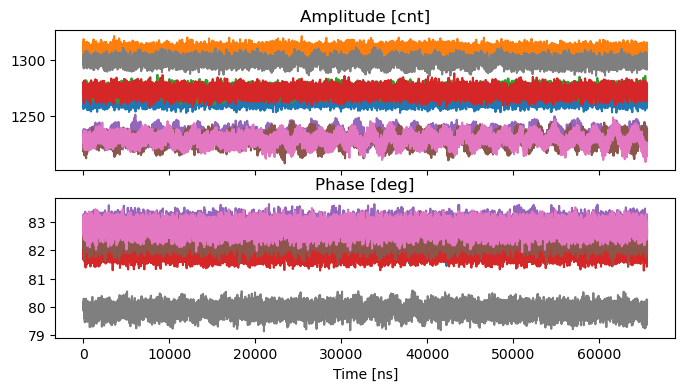

In [14]:
cdata_dsp = get_dsp_waveform()
plot_complex_wfm_stack(cdata_dsp, fs=fs/2, mode='ap')

# Check LLRF pulsing mode

In [15]:
ol.rf_control.register_map.dac_enable.pulse_enable=1
ol.rf_control.register_map.pulse_length=100

Expect 4 ns * 100 = 400 ns pulse length

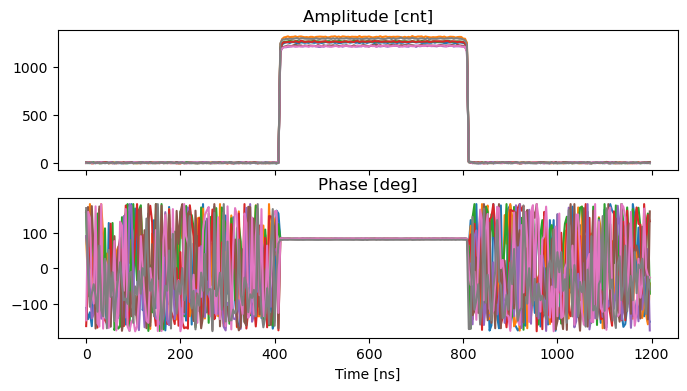

In [16]:
cdata_dsp = get_dsp_waveform()
plot_complex_wfm_stack(cdata_dsp[:, :300], fs=fs/2, mode='ap')

# Plot DAC waveform

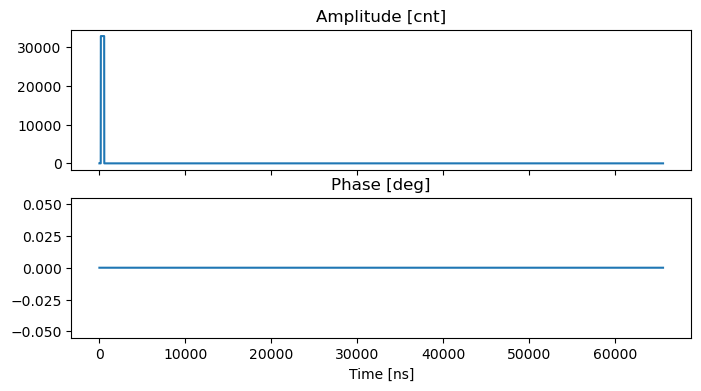

In [17]:
darray_i, darray_q = ol.capture_dac_iq_buf()
dac_c = darray_i + 1j*darray_q
plot_complex_wfm_stack(np.array([dac_c]), fs=fs, mode='ap')